Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\io\image.py:14: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Initializations


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 10
NUM_FOLDS = 5

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Dataset Preparation

In [5]:
train_dataset = datasets.ImageFolder(root="./CIFAKE/train", transform=transform)
test_dataset = datasets.ImageFolder(root="./CIFAKE/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

CNN Implementation

In [6]:
class CIFAKE_CNN(nn.Module):
    def __init__(self):
        super(CIFAKE_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 1)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [7]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.float().to(device)
        labels = labels.view(-1, 1)  # Reshape for BCEWithLogitsLoss
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

In [8]:
def evaluate(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).cpu().numpy()
            preds = (outputs > 0.5).astype(int)  # Convert sigmoid output to binary
            
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_preds)

    return acc, precision, recall, f1, roc_auc

Cross Validation

In [9]:
def cross_validate_with_plots(dataset, model_class, k_folds=NUM_FOLDS):
    kfold = KFold(n_splits=k_folds, shuffle=True)
    
    scores = {"accuracy": [], "precision": [], "recall": [], "f1_score": [], "roc_auc": []}

    for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset)):
        print(f"\nFold {fold+1}/{k_folds}")

        # Prepare train and validation datasets
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

        # Initialize model
        model = model_class().to(device)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=LR)

        train_losses, val_losses = [], []  # Store loss values

        for epoch in range(EPOCHS):
            # Training
            model.train()
            total_train_loss = 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.float().to(device).view(-1, 1)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                total_train_loss += loss.item()
            
            avg_train_loss = total_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Validation
            model.eval()
            total_val_loss = 0
            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.float().to(device).view(-1, 1)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    total_val_loss += loss.item()
                    probs = outputs.cpu().numpy().flatten()
                    preds = (probs > 0.5).astype(int)

                    all_probs.extend(probs)
                    all_preds.extend(preds)
                    all_labels.extend(labels.cpu().numpy().flatten())

            avg_val_loss = total_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)

            print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

        # Compute metrics
        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)
        roc_auc = roc_auc_score(all_labels, all_probs)

        scores["accuracy"].append(acc)
        scores["precision"].append(precision)
        scores["recall"].append(recall)
        scores["f1_score"].append(f1)
        scores["roc_auc"].append(roc_auc)

        print(f"Fold {fold+1} Metrics - Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, "
              f"F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

        # --- Plot Training vs Validation Loss ---
        plt.figure(figsize=(6, 5))
        plt.plot(range(1, EPOCHS + 1), train_losses, label="Training Loss", marker="o")
        plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss", marker="o")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Training vs Validation Loss (Fold {fold+1})")
        plt.legend()
        plt.show()

        # --- Plot ROC Curve ---
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve (Fold {fold+1})")
        plt.legend(loc="lower right")
        plt.show()

    # Print average cross-validation results
    print("\nCross-validation Summary:")
    for metric, values in scores.items():
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")


Fold 1/5
Epoch 1: Train Loss = 0.2715, Val Loss = 0.2030
Epoch 2: Train Loss = 0.1728, Val Loss = 0.1644
Epoch 3: Train Loss = 0.1429, Val Loss = 0.1703
Epoch 4: Train Loss = 0.1216, Val Loss = 0.1495
Epoch 5: Train Loss = 0.1002, Val Loss = 0.1409
Epoch 6: Train Loss = 0.0838, Val Loss = 0.1483
Epoch 7: Train Loss = 0.0664, Val Loss = 0.1426
Epoch 8: Train Loss = 0.0509, Val Loss = 0.1537
Epoch 9: Train Loss = 0.0406, Val Loss = 0.1850
Epoch 10: Train Loss = 0.0317, Val Loss = 0.2014
Fold 1 Metrics - Accuracy: 0.9456, Precision: 0.9471, Recall: 0.9433, F1-Score: 0.9452, ROC-AUC: 0.9874



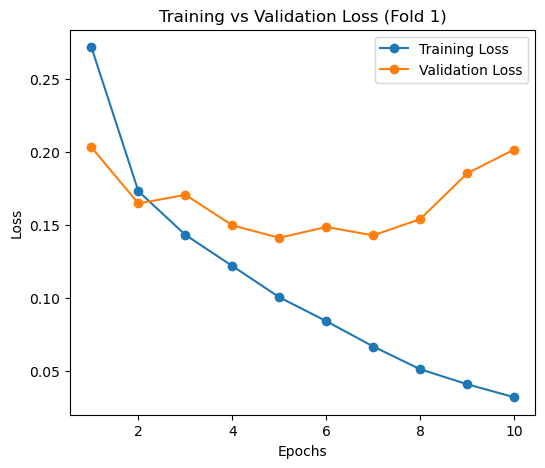

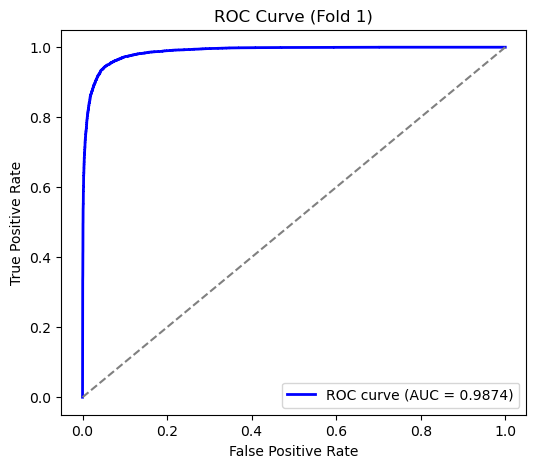


Fold 2/5
Epoch 1: Train Loss = 0.2810, Val Loss = 0.2216
Epoch 2: Train Loss = 0.1720, Val Loss = 0.2222
Epoch 3: Train Loss = 0.1418, Val Loss = 0.1541
Epoch 4: Train Loss = 0.1186, Val Loss = 0.1595
Epoch 5: Train Loss = 0.1004, Val Loss = 0.1327
Epoch 6: Train Loss = 0.0809, Val Loss = 0.1377
Epoch 7: Train Loss = 0.0660, Val Loss = 0.1447
Epoch 8: Train Loss = 0.0522, Val Loss = 0.1657
Epoch 9: Train Loss = 0.0395, Val Loss = 0.1745
Epoch 10: Train Loss = 0.0330, Val Loss = 0.2071
Fold 2 Metrics - Accuracy: 0.9459, Precision: 0.9587, Recall: 0.9320, F1-Score: 0.9452, ROC-AUC: 0.9888



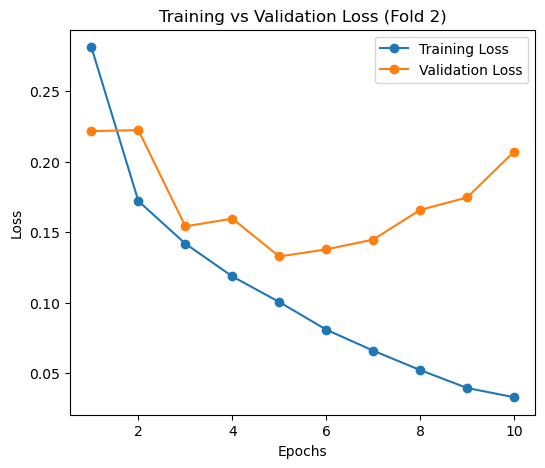

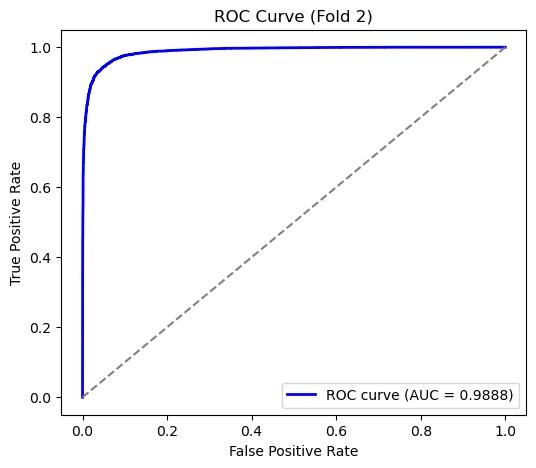


Fold 3/5
Epoch 1: Train Loss = 0.2851, Val Loss = 0.1927
Epoch 2: Train Loss = 0.1791, Val Loss = 0.1671
Epoch 3: Train Loss = 0.1459, Val Loss = 0.1579
Epoch 4: Train Loss = 0.1248, Val Loss = 0.1459
Epoch 5: Train Loss = 0.1043, Val Loss = 0.1433
Epoch 6: Train Loss = 0.0866, Val Loss = 0.1423
Epoch 7: Train Loss = 0.0686, Val Loss = 0.1678
Epoch 8: Train Loss = 0.0543, Val Loss = 0.1512
Epoch 9: Train Loss = 0.0425, Val Loss = 0.2342
Epoch 10: Train Loss = 0.0344, Val Loss = 0.1974
Fold 3 Metrics - Accuracy: 0.9454, Precision: 0.9316, Recall: 0.9609, F1-Score: 0.9460, ROC-AUC: 0.9882



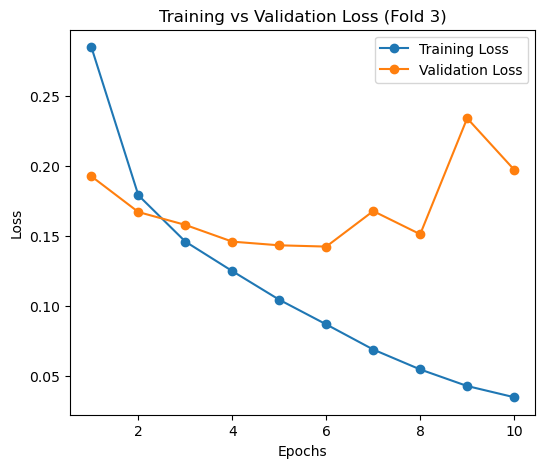

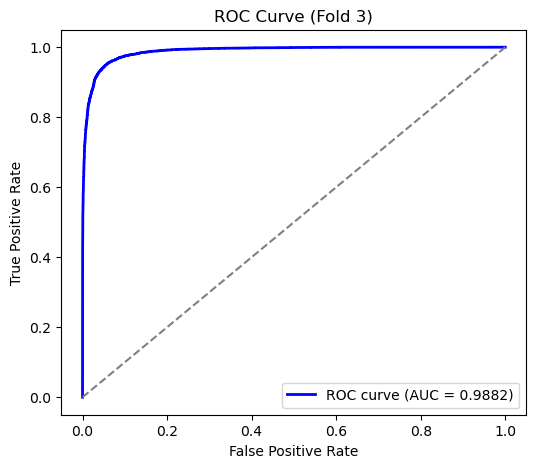


Fold 4/5
Epoch 1: Train Loss = 0.2666, Val Loss = 0.1729
Epoch 2: Train Loss = 0.1696, Val Loss = 0.1485
Epoch 3: Train Loss = 0.1374, Val Loss = 0.1497
Epoch 4: Train Loss = 0.1154, Val Loss = 0.1546
Epoch 5: Train Loss = 0.0945, Val Loss = 0.1381
Epoch 6: Train Loss = 0.0758, Val Loss = 0.1412
Epoch 7: Train Loss = 0.0616, Val Loss = 0.1425
Epoch 8: Train Loss = 0.0464, Val Loss = 0.1622
Epoch 9: Train Loss = 0.0369, Val Loss = 0.1844
Epoch 10: Train Loss = 0.0295, Val Loss = 0.1898
Fold 4 Metrics - Accuracy: 0.9507, Precision: 0.9580, Recall: 0.9434, F1-Score: 0.9506, ROC-AUC: 0.9894



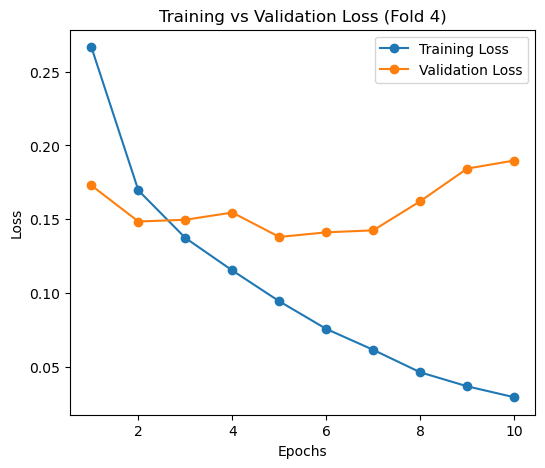

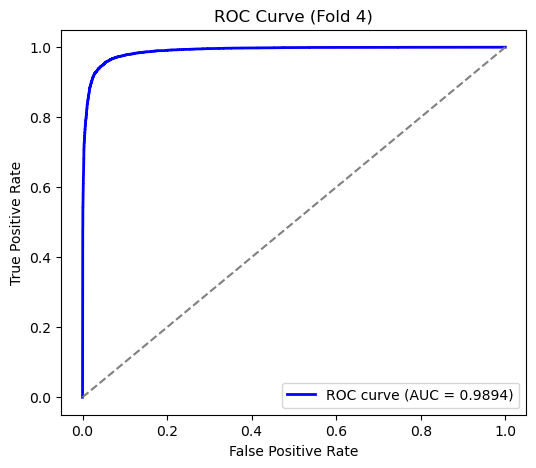


Fold 5/5
Epoch 1: Train Loss = 0.2803, Val Loss = 0.1954
Epoch 2: Train Loss = 0.1745, Val Loss = 0.1710
Epoch 3: Train Loss = 0.1436, Val Loss = 0.2541
Epoch 4: Train Loss = 0.1232, Val Loss = 0.1538
Epoch 5: Train Loss = 0.1060, Val Loss = 0.1295
Epoch 6: Train Loss = 0.0874, Val Loss = 0.1293
Epoch 7: Train Loss = 0.0714, Val Loss = 0.1464
Epoch 8: Train Loss = 0.0588, Val Loss = 0.1511
Epoch 9: Train Loss = 0.0451, Val Loss = 0.2042
Epoch 10: Train Loss = 0.0383, Val Loss = 0.2515
Fold 5 Metrics - Accuracy: 0.9378, Precision: 0.9093, Recall: 0.9732, F1-Score: 0.9401, ROC-AUC: 0.9881



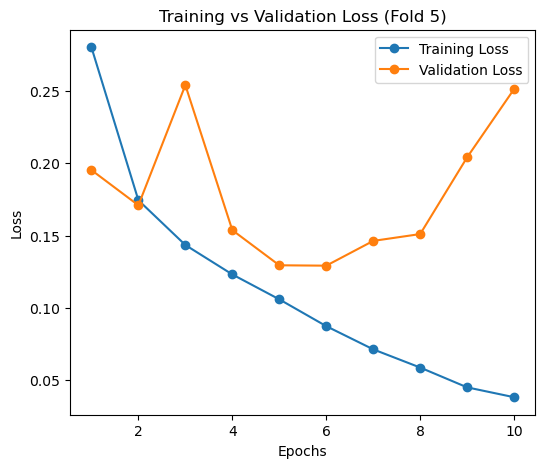

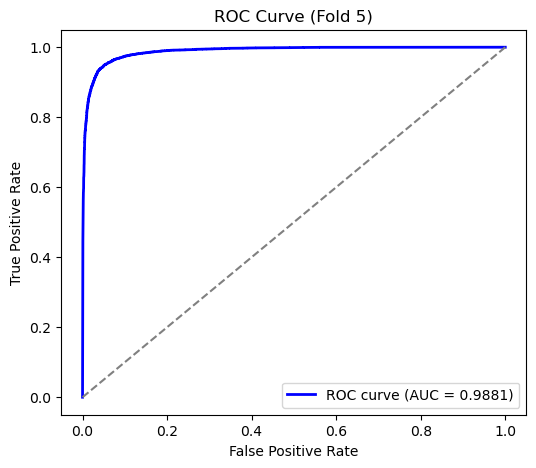


Cross-validation Summary:
accuracy: 0.9451 ± 0.0041
precision: 0.9409 ± 0.0186
recall: 0.9506 ± 0.0146
f1_score: 0.9454 ± 0.0033
roc_auc: 0.9884 ± 0.0007


In [10]:
cross_validate_with_plots(train_dataset, CIFAKE_CNN)

In [11]:
final_model = CIFAKE_CNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(final_model.parameters(), lr=LR)

In [12]:
for epoch in range(EPOCHS):
    train_loss = train(final_model, train_loader, criterion, optimizer, device)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

Epoch 1, Train Loss: 0.2601
Epoch 2, Train Loss: 0.1635
Epoch 3, Train Loss: 0.1340
Epoch 4, Train Loss: 0.1097
Epoch 5, Train Loss: 0.0907
Epoch 6, Train Loss: 0.0747
Epoch 7, Train Loss: 0.0605
Epoch 8, Train Loss: 0.0468
Epoch 9, Train Loss: 0.0380
Epoch 10, Train Loss: 0.0318


Evaluation

In [13]:
acc, precision, recall, f1, roc_auc = evaluate(final_model, test_loader, device)
print(f"Test Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, "
      f"F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

Test Accuracy: 0.9538, Precision: 0.9437, Recall: 0.9652, F1-Score: 0.9543, ROC-AUC: 0.9538


Saving the Model

In [ ]:
# Save the model after training
MODEL_PATH = "Models/cifake_cnn.pth"
torch.save(final_model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to cifake_cnn.pth


Loading the Model

In [15]:
# Load the model
loaded_model = CIFAKE_CNN().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()  # Set to evaluation mode
print("Model loaded successfully!")

Model loaded successfully!


C:\Users\sapat\AppData\Local\Temp\ipykernel_39436\3306830167.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(MODEL_PATH))


In [16]:
def predict(image):
    loaded_model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0)  # Add batch dimension
        output = loaded_model(image)
        prediction = "FAKE" if output.item() > 0.5 else "REAL"
    return prediction

Confusino Matrix

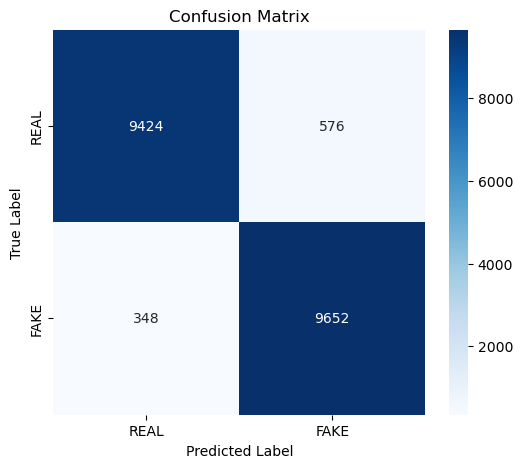

In [17]:
def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).cpu().numpy()
            preds = (outputs > 0.5).astype(int)  # Convert sigmoid output to binary
            
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call function to plot confusion matrix
plot_confusion_matrix(final_model, test_loader)

ROC Curve

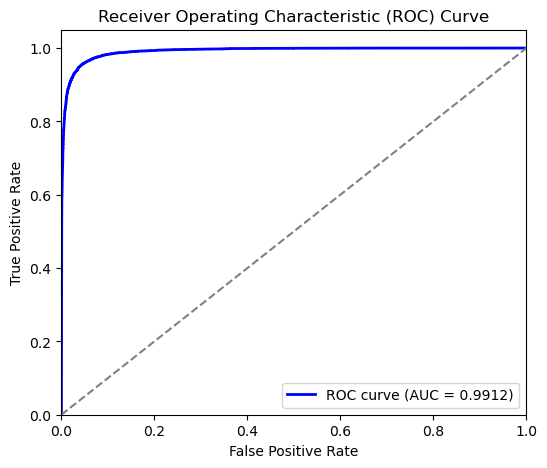

In [18]:
def plot_roc_curve(model, test_loader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).cpu().numpy()
            
            all_probs.extend(outputs.flatten())  # Get probabilities
            all_labels.extend(labels.cpu().numpy().flatten())

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

# Call function to plot ROC curve
plot_roc_curve(final_model, test_loader)